To help make some useful figures, pulling in saved data

In [2]:
# --- Cell 1: Load the cleaned CONUS modelling dataset ---

import pandas as pd

data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\event_level_dataset_conus_modeling_valid.parquet"

event_df = pd.read_parquet(data_path)

event_df["CountyFIPS"] = event_df["CountyFIPS"].astype(str).str.zfill(5)
event_df["storm"] = event_df["storm"].astype(str)

if "t90" not in event_df.columns and "t90_lastcross" in event_df.columns:
    event_df["t90"] = event_df["t90_lastcross"]

print("Loaded cleaned CONUS modelling dataset")
print("Shape:", event_df.shape)
print("Columns:", event_df.columns.tolist())
print()
print(event_df.head().to_string(index=False))

Loaded cleaned CONUS modelling dataset
Shape: (913, 42)
Columns: ['event_id', 'storm', 'CountyFIPS', 'county', 'event_start', 'duration_hours', 'county_pop', 'pre_outage_tracked_customers', 'days_since_data_start', 'n_periods', 'integral', 'pop_hours_supply_lost', 'duration_days', 'year', 'month', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'weather_hours_available', 'weather_hours_used', 'matched_ibtracs_storm', 'min_dist_to_storm_km', 'county_gdp_real_2017_dollars', 'county_gdp_real_2017_per_capita', 'storm_max_wind_center_in_conus_mps', 'storm_max_wind_near_conus_mps', 't90_lastcross', 'censored_lastcross', 'crossing_time_lastcross', 't50', 't50_censored', 'peak_outage_clean_t50', 'threshold_used_t50', 'crossing_time_t50', 'max_outage_raw', 'hours_above_thresh_raw', 'n_ts_points', 'is_valid', 't90', 't90_censored', 'peak_outage_clean']

                 event_id         storm CountyFIPS       county         event_start  duration_hours  county_pop  pre_outage_tr

This histogram shows the distribution of t90 across the cleaned CONUS modelling dataset.
It is useful for checking the overall recovery-time spread and whether the target has a long tail.


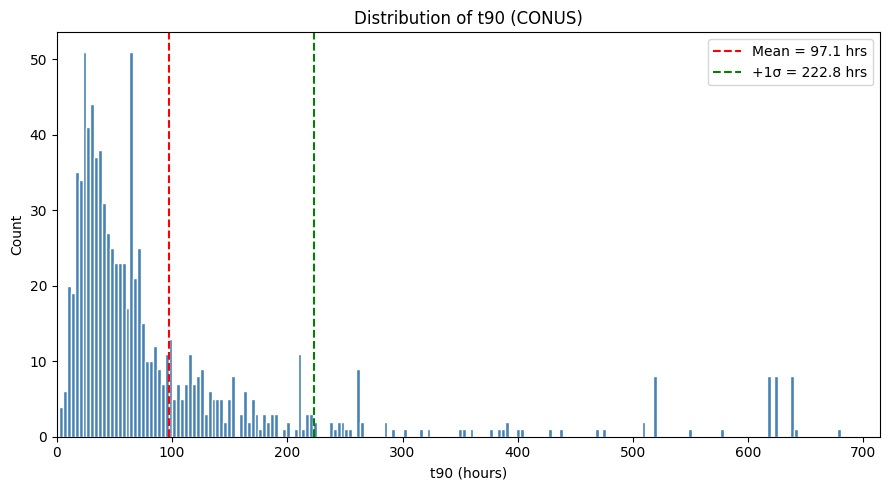


Interpretation note:
If this is strongly right-skewed, that means a small number of long recovery events are stretching the tail.
That is relevant for model choice, because tree-based models usually handle this kind of distribution better than a linear model.


In [8]:
# --- Cell 2: Histogram of t90 ---

import matplotlib.pyplot as plt
import numpy as np

if "t90" not in event_df.columns:
    raise RuntimeError("t90 is missing from event_df.")

t90_vals = event_df["t90"].dropna().astype(float)

print(
    "This histogram shows the distribution of t90 across the cleaned CONUS modelling dataset.\n"
    "It is useful for checking the overall recovery-time spread and whether the target has a long tail."
)

mean_t90 = t90_vals.mean()
std_t90 = t90_vals.std(ddof=0)
upper_1sd = mean_t90 + std_t90
lower_1sd = mean_t90 - std_t90

plt.figure(figsize=(9, 5))
plt.hist(t90_vals, bins=200, color="steelblue", edgecolor="white")

plt.axvline(mean_t90, color="red", linestyle="--", linewidth=1.5, label=f"Mean = {mean_t90:.1f} hrs")

if lower_1sd > 0:
    plt.axvline(lower_1sd, color="green", linestyle="--", linewidth=1.5, label=f"-1σ = {lower_1sd:.1f} hrs")

plt.axvline(upper_1sd, color="green", linestyle="--", linewidth=1.5, label=f"+1σ = {upper_1sd:.1f} hrs")

plt.xlabel("t90 (hours)")
plt.ylabel("Count")
plt.title("Distribution of t90 (CONUS)")
plt.xlim(left=0)
plt.legend()
plt.tight_layout()
plt.show()

print(
    "\nInterpretation note:\n"
    "If this is strongly right-skewed, that means a small number of long recovery events are stretching the tail.\n"
    "That is relevant for model choice, because tree-based models usually handle this kind of distribution better than a linear model."
)

This map shows how many county-event observations are present in the cleaned CONUS modelling dataset.
It is a frequency map, not a severity map: counties with more event rows are darker.
A log colour scale is used because counts are uneven.


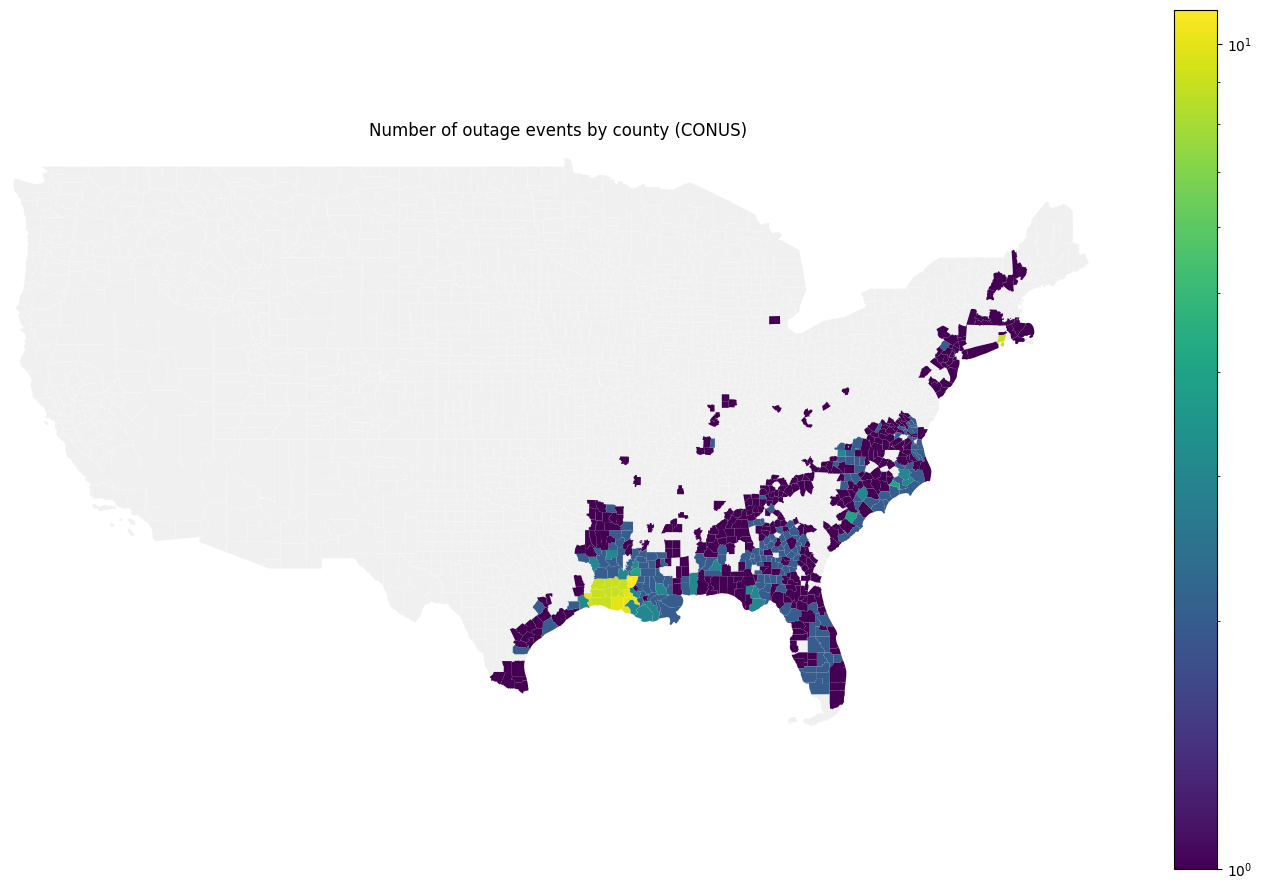


Interpretation note:
This is counting county-event rows, not unique storms.
A county can appear more than once if it is affected by multiple named storms or multiple event windows.


In [9]:
# --- Cell 3: County map showing number of outage events ---

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

print(
    "This map shows how many county-event observations are present in the cleaned CONUS modelling dataset.\n"
    "It is a frequency map, not a severity map: counties with more event rows are darker.\n"
    "A log colour scale is used because counts are uneven."
)

county_counts = (
    event_df.groupby("CountyFIPS")
    .size()
    .reset_index(name="event_count")
)

# County geometries from Census TIGER/Line
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip"
)

counties["CountyFIPS"] = (counties["STATEFP"] + counties["COUNTYFP"]).astype(str).str.zfill(5)

# Keep lower 48 + DC only
exclude_state_fips = {"02", "15", "60", "66", "69", "72", "78"}
counties = counties[~counties["STATEFP"].isin(exclude_state_fips)].copy()

# Merge counts
counties = counties.merge(county_counts, on="CountyFIPS", how="left")
counties["event_count"] = counties["event_count"].fillna(0)

# Split for plotting
plot_df = counties[counties["event_count"] > 0].copy()
no_event_df = counties[counties["event_count"] == 0].copy()

fig, ax = plt.subplots(figsize=(14, 9))

# Light grey background counties
if len(no_event_df) > 0:
    no_event_df.plot(
        ax=ax,
        color="#f0f0f0",
        edgecolor="white",
        linewidth=0.1
    )

# Counties with events, using log scale
if len(plot_df) > 0:
    plot_df.plot(
        ax=ax,
        column="event_count",
        cmap="viridis",
        norm=LogNorm(
            vmin=max(1, plot_df["event_count"].min()),
            vmax=plot_df["event_count"].max()
        ),
        legend=True,
        edgecolor="none"
    )

# Crop to CONUS so Alaska/Hawaii are not shown in the frame
ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)

ax.set_title("Number of outage events by county (CONUS)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(
    "\nInterpretation note:\n"
    "This is counting county-event rows, not unique storms.\n"
    "A county can appear more than once if it is affected by multiple named storms or multiple event windows."
)